<a href="https://colab.research.google.com/github/hillarymaximino/metodos_numericos/blob/main/Atividade_09_M%C3%A9todos_N%C3%BAmericos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget -q https://raw.githubusercontent.com/numpy/numpy-tutorials/main/content/tutorial-x-ray-image-processing/00000011_001.png

In [ ]:
import imageio

xray_image = imageio.v3.imread("00000011_001.png")

print(xray_image.shape)
print(xray_image.dtype)

(1024, 1024)
uint8


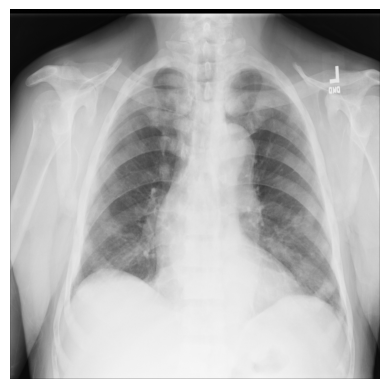

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.imshow(xray_image, cmap="gray")
ax.set_axis_off()

In [ ]:
!git clone -q https://github.com/numpy/numpy-tutorials.git

In [ ]:
import os
DIR = "numpy-tutorials/content/tutorial-x-ray-image-processing"

In [ ]:
import os

DIR = "numpy-tutorials/content/tutorial-x-ray-image-processing"

print(os.listdir(DIR))

['00000011_002.png', '00000011_003.png', '00000011_007.png', '00000011_001.png', '00000011_006.png', '00000011_004.png', '00000011_005.png', '00000011_000.png', '00000011_008.png']


In [ ]:
combined_xray_images_1.shape

(9, 1024, 1024)

In [ ]:
import numpy as np
num_imgs = 9

combined_xray_images_1 = np.array(
    [imageio.v3.imread(os.path.join(DIR, f"00000011_00{i}.png")) for i in range(num_imgs)]
)

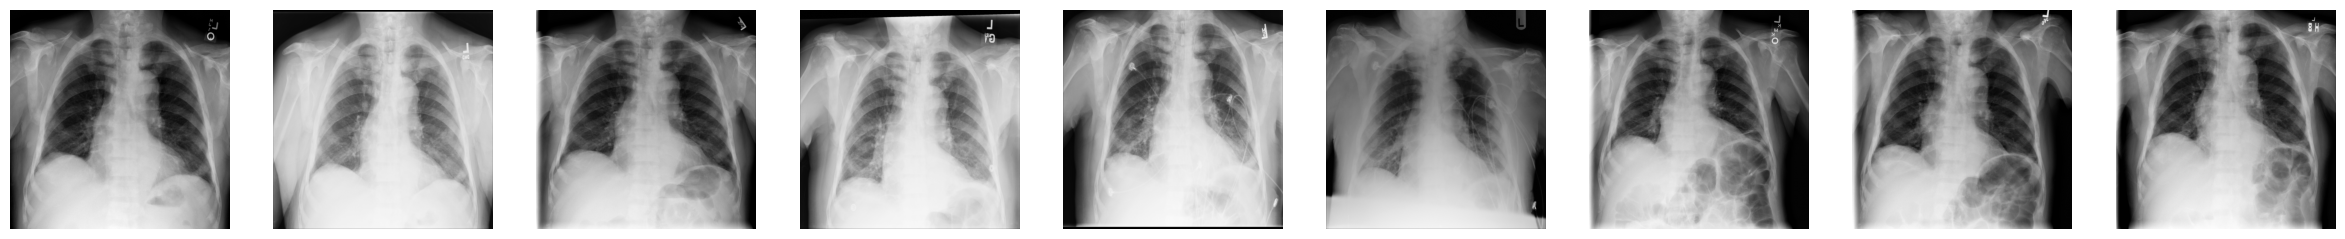

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=num_imgs, figsize=(30, 30))

for img, ax in zip(combined_xray_images_1, axes):
    ax.imshow(img, cmap='gray')
    ax.axis('off')

In [ ]:
GIF_PATH = os.path.join(DIR, "xray_image.gif")
imageio.mimwrite(GIF_PATH, combined_xray_images_1, format= ".gif", duration=1000)

In [ ]:
from scipy import ndimage

xray_image_laplace_gaussian = ndimage.gaussian_laplace(xray_image, sigma=1)

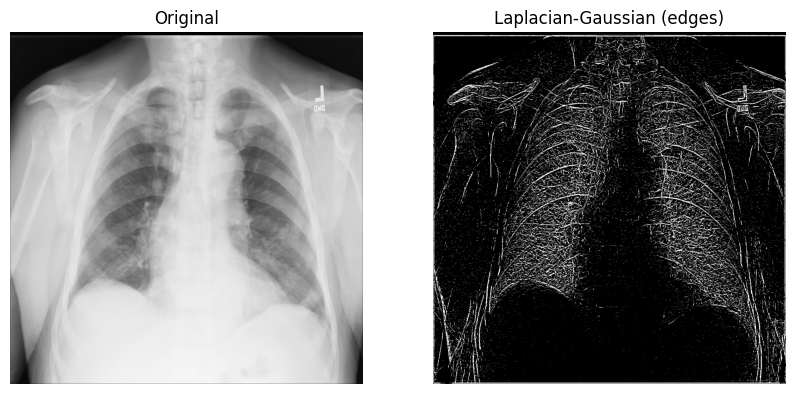

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 10))

axes[0].set_title("Original")
axes[0].imshow(xray_image, cmap="gray")
axes[1].set_title("Laplacian-Gaussian (edges)")
axes[1].imshow(xray_image_laplace_gaussian, cmap="gray")
for i in axes:
    i.axis("off")

In [ ]:
x_ray_image_gaussian_gradient = ndimage.gaussian_gradient_magnitude(xray_image, sigma=2)

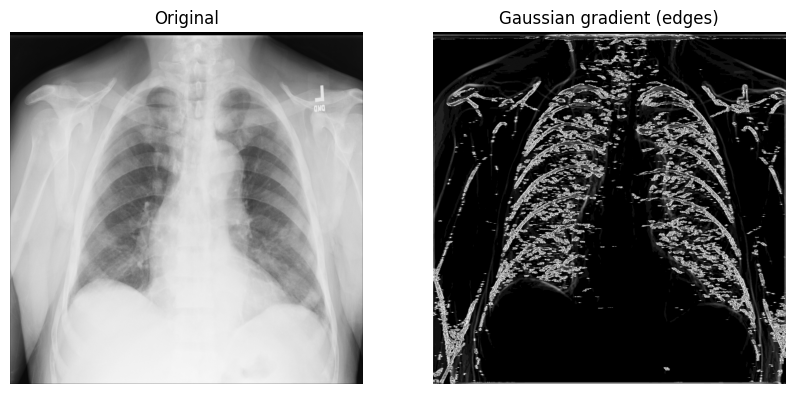

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 10))

axes[0].set_title("Original")
axes[0].imshow(xray_image, cmap="gray")
axes[1].set_title("Gaussian gradient (edges)")
axes[1].imshow(x_ray_image_gaussian_gradient, cmap="gray")
for i in axes:
    i.axis("off")

In [ ]:
x_sobel = ndimage.sobel(xray_image, axis=0)
y_sobel = ndimage.sobel(xray_image, axis=1)

xray_image_sobel = np.hypot(x_sobel, y_sobel)

xray_image_sobel *= 255.0 / np.max(xray_image_sobel)

In [ ]:
print("The data type - before: ", xray_image_sobel.dtype)

xray_image_sobel = xray_image_sobel.astype("float32")

print("The data type - after: ", xray_image_sobel.dtype)

The data type - before:  float16
The data type - after:  float32


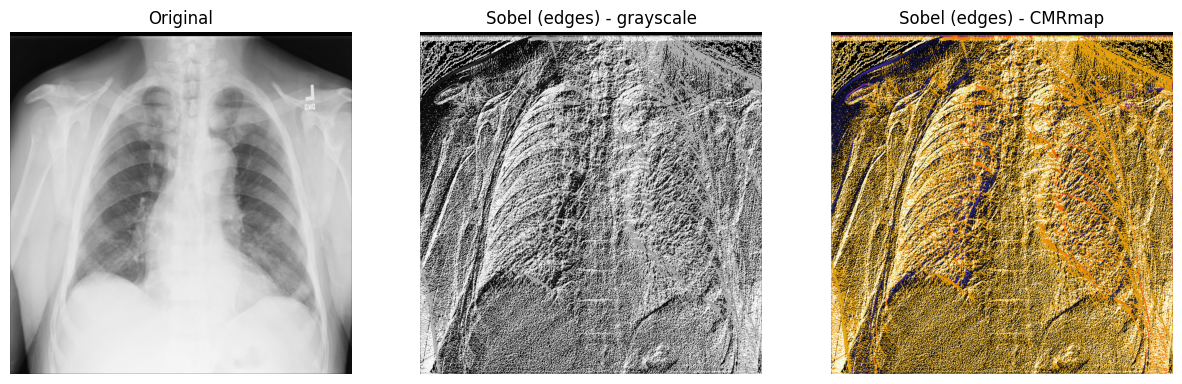

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 15))

axes[0].set_title("Original")
axes[0].imshow(xray_image, cmap="gray")
axes[1].set_title("Sobel (edges) - grayscale")
axes[1].imshow(xray_image_sobel, cmap="gray")
axes[2].set_title("Sobel (edges) - CMRmap")
axes[2].imshow(xray_image_sobel, cmap="CMRmap")
for i in axes:
    i.axis("off")

In [ ]:
fourier_gaussian = ndimage.fourier_gaussian(xray_image, sigma=0.05)

x_prewitt = ndimage.prewitt(fourier_gaussian, axis=0)
y_prewitt = ndimage.prewitt(fourier_gaussian, axis=1)

xray_image_canny = np.hypot(x_prewitt, y_prewitt)

xray_image_canny *= 255.0 / np.max(xray_image_canny)

print("The data type - ", xray_image_canny.dtype)

The data type -  float64


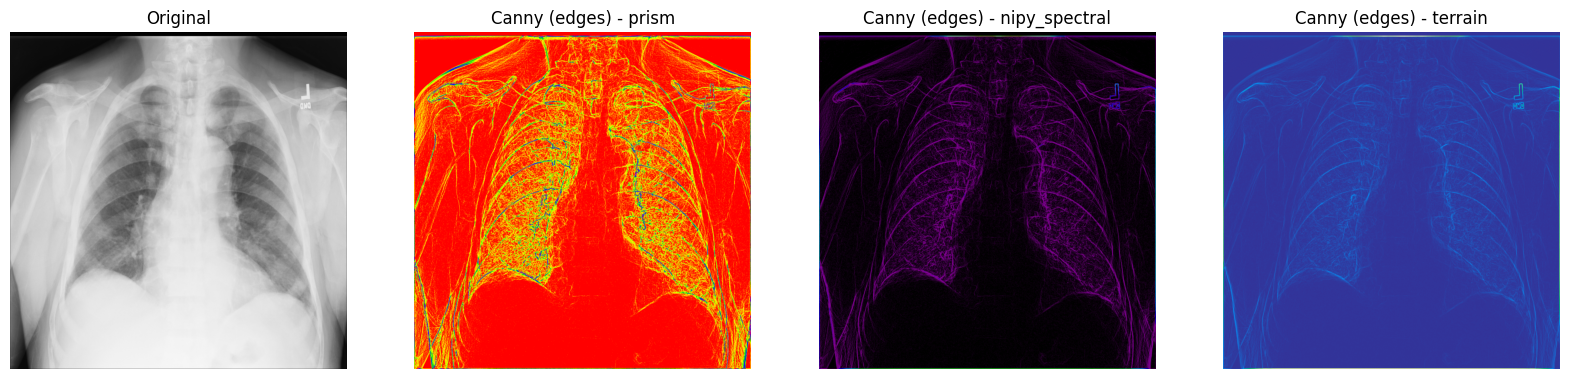

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 15))

axes[0].set_title("Original")
axes[0].imshow(xray_image, cmap="gray")
axes[1].set_title("Canny (edges) - prism")
axes[1].imshow(xray_image_canny, cmap="prism")
axes[2].set_title("Canny (edges) - nipy_spectral")
axes[2].imshow(xray_image_canny, cmap="nipy_spectral")
axes[3].set_title("Canny (edges) - terrain")
axes[3].imshow(xray_image_canny, cmap="terrain")
for i in axes:
    i.axis("off")

In [ ]:
print("The data type of the X-ray image is: ", xray_image.dtype)
print("The minimum pixel value is: ", np.min(xray_image))
print("The maximum pixel value is: ", np.max(xray_image))
print("The average pixel value is: ", np.mean(xray_image))
print("The median pixel value is: ", np.median(xray_image))

The data type of the X-ray image is:  uint8
The minimum pixel value is:  0
The maximum pixel value is:  255
The average pixel value is:  172.52233219146729
The median pixel value is:  195.0


Text(0.5, 1.0, 'Pixel intensity distribution')

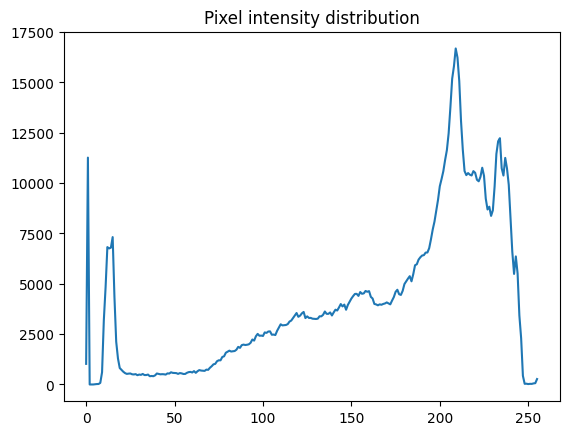

In [ ]:
pixel_intensity_distribution = ndimage.histogram(
    xray_image, min=np.min(xray_image), max=np.max(xray_image), bins=256
)

fig, ax = plt.subplots()
ax.plot(pixel_intensity_distribution)
ax.set_title("Pixel intensity distribution")

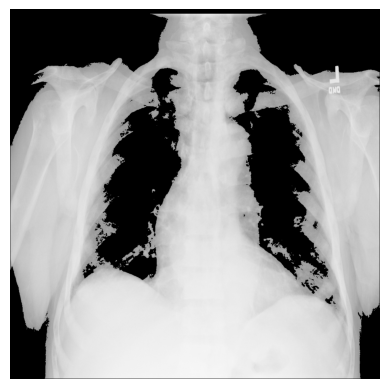

In [ ]:
# The threshold is "greater than 150"
# Return the original image if true, `0` otherwise
xray_image_mask_noisy = np.where(xray_image > 150, xray_image, 0)

fig, ax = plt.subplots()
ax.imshow(xray_image_mask_noisy, cmap="gray")
ax.set_axis_off()

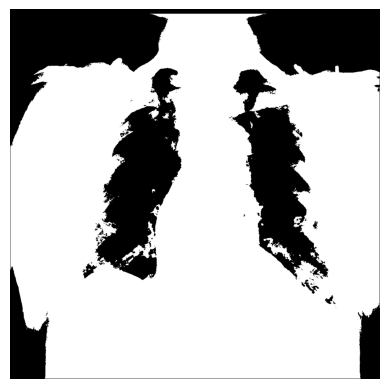

In [ ]:
# The threshold is "greater than 150"
# Return `1` if true, `0` otherwise
xray_image_mask_less_noisy = np.where(xray_image > 150, 1, 0)

fig, ax = plt.subplots()
ax.imshow(xray_image_mask_less_noisy, cmap="gray")
ax.set_axis_off()

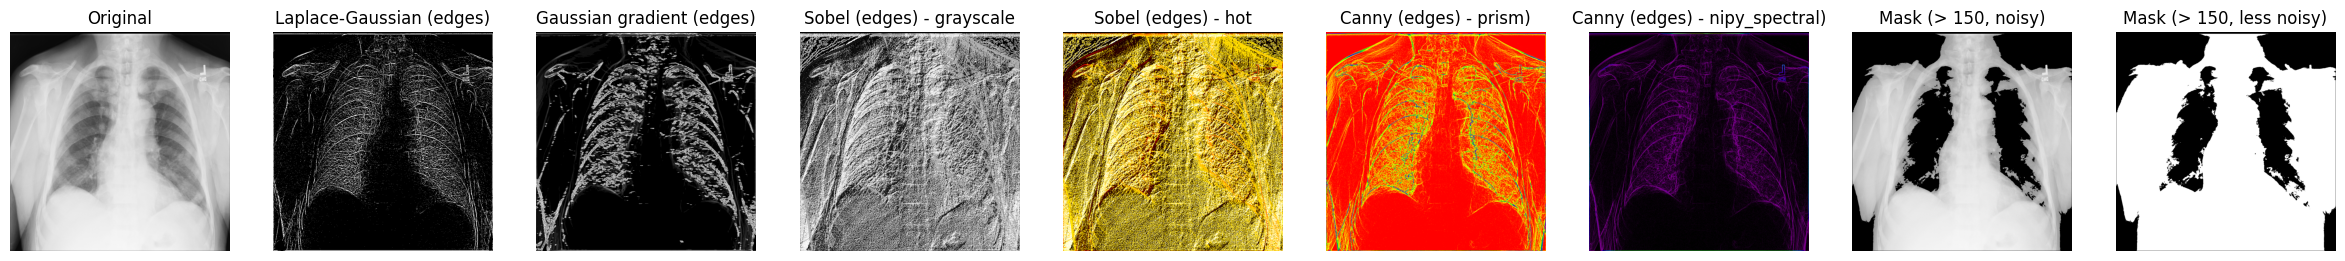

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=9, figsize=(30, 30))

axes[0].set_title("Original")
axes[0].imshow(xray_image, cmap="gray")
axes[1].set_title("Laplace-Gaussian (edges)")
axes[1].imshow(xray_image_laplace_gaussian, cmap="gray")
axes[2].set_title("Gaussian gradient (edges)")
axes[2].imshow(x_ray_image_gaussian_gradient, cmap="gray")
axes[3].set_title("Sobel (edges) - grayscale")
axes[3].imshow(xray_image_sobel, cmap="gray")
axes[4].set_title("Sobel (edges) - hot")
axes[4].imshow(xray_image_sobel, cmap="hot")
axes[5].set_title("Canny (edges) - prism)")
axes[5].imshow(xray_image_canny, cmap="prism")
axes[6].set_title("Canny (edges) - nipy_spectral)")
axes[6].imshow(xray_image_canny, cmap="nipy_spectral")
axes[7].set_title("Mask (> 150, noisy)")
axes[7].imshow(xray_image_mask_noisy, cmap="gray")
axes[8].set_title("Mask (> 150, less noisy)")
axes[8].imshow(xray_image_mask_less_noisy, cmap="gray")
for i in axes:
    i.axis("off")

# **1) explique, com suas palavras e com base nos conceitos trabalhados sobre vetores e matrizes e na discussão apresentada no documento detecao_borda_imagem.pdf, como a operação entre filtros e imagens possibilita a detecção de bordas, considerando cada um dos kernels testados.**

# Na prática, o processo interpreta a imagem como uma tabela ou matriz gigante de números, enquanto o kernel é uma matriz bem menor. A operação consiste em arrastar esse filtro por toda a imagem, multiplicando os valores da imagem pelos valores do filtro que ficam sobrepostos e somando tudo. Esse resultado único transforma-se no novo píxel da imagem gerada.

# **No caso dos filtros focados em encontrar bordas, eles são montados intercalando valores positivos e negativos. Quando a matriz passa por uma zona da imagem sem detalhes, as multiplicações cancelam-se e a soma é zero. Mas, quando o filtro cruza uma mudança brusca de cor ou intensidade, a soma dá um número elevado, fazendo com que o contorno fique aceso e destacado na imagem final.**

# **Já o filtro Gaussiano age de forma diferente, servindo para suavizar a imagem. Como os números que o compõem somam exatamente 1, o que a operação matemática faz na verdade é calcular uma média dos píxeis vizinhos. O efeito final é um desfoque geral que mistura os detalhes, em vez de detetar e marcar as bordas**